In [1]:
import matplotlib.pyplot as plt
import matplotlib
plt.rcParams['font.size'] = 9
import json
import numpy as np

In [2]:
with open('data/yolo/output/sahi_comparison_metrics.json') as f:
    data = json.load(f)

In [3]:
def get_precision_recall_at_conf(data, conf_value=0.5):
    results = {}
    for mode in ["tiling", "whole"]:
        mode_data = data.get(mode, {})
        precision_curve = mode_data.get("Precision-Confidence(B)", {})
        recall_curve = mode_data.get("Recall-Confidence(B)", {})
        f1_curve = mode_data.get("F1-Confidence(B)", {})

        x_prec = precision_curve.get("x", [])
        y_prec = precision_curve.get("y", [])
        x_rec = recall_curve.get("x", [])
        y_rec = recall_curve.get("y", [])
        x_f1 = f1_curve.get("x", [])
        y_f1 = f1_curve.get("y", [])

        if x_prec and y_prec:
            idx_p = min(range(len(x_prec)), key=lambda i: abs(x_prec[i] - conf_value))
            precision = y_prec[idx_p]
        else:
            precision = None

        if x_rec and y_rec:
            idx_r = min(range(len(x_rec)), key=lambda i: abs(x_rec[i] - conf_value))
            recall = y_rec[idx_r]
        else:
            recall = None

        if x_f1 and y_f1:
            idx_f = min(range(len(x_f1)), key=lambda i: abs(x_f1[i] - conf_value))
            f1 = y_f1[idx_f]
        else:
            f1 = None

        results[mode] = {
            "conf": conf_value,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        }

    return results

results_at_05 = get_precision_recall_at_conf(data, 0.5)
results_at_05


{'tiling': {'conf': 0.5,
  'precision': 0.9951661838031974,
  'recall': 0.9680690114457078,
  'f1': 0.9814305958959924},
 'whole': {'conf': 0.5,
  'precision': 0.9962175650074208,
  'recall': 0.8779361597305105,
  'f1': 0.9333443801692366}}

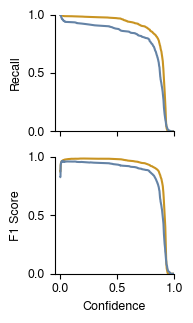

In [4]:
colors = ["#C99422", "#6483A6"]

fig, ax = plt.subplots(2,1, sharex=True, figsize = (2,3.3))
for i, key in enumerate(data.keys()):
    color = colors[i]
    ax[0].plot(data[key]['Recall-Confidence(B)']['x'], data[key]['Recall-Confidence(B)']['y'], color=color)
    ax[1].plot(data[key]['F1-Confidence(B)']['x'], data[key]['F1-Confidence(B)']['y'], color=color)

ax[0].set_ylabel('Recall')

ax[1].set_ylabel('F1 Score')
ax[1].set_xlabel('Confidence')

for axis in ax:
    axis.set_ylim(0,1)
    axis.set_yticks([0, 0.5, 1])
    axis.set_xlim(-.05,1)
    axis.set_xticks([0, 0.5, 1])

plt.tight_layout()
plt.savefig('figs/recall_f1.svg', format='svg')